In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.patches as patches
from sklearn.metrics import pairwise_distances
from scipy.optimize import linear_sum_assignment

In [12]:
lena = plt.imread('Lena_2048.png')[:,:,:3] #https://ru.wikipedia.org/wiki/%D0%A4%D0%B0%D0%B9%D0%BB:President_Barack_Obama.jpg
obama = plt.imread('Obama.png')[:,:,:3] #https://mortenhannemose.github.io/lena/

In [28]:
def match_image_colors(img1, img2, n_clusters=30):
    # 1. Подготовка данных: преобразуем изображения в двумерные массивы пикселей
    # Формат: (количество_пикселей, 3 цвета RGB)
    pixels1 = img1.reshape(-1, 3)
    pixels2 = img2.reshape(-1, 3)
    
    # 2. Кластеризация KMeans (поиск 30 центроид для каждого изображения)
    print("Вычисляем кластеры для первого изображения...")
    kmeans1 = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans1.fit(pixels1)
    centroids1 = kmeans1.cluster_centers_
    
    print("Вычисляем кластеры для второго изображения...")
    kmeans2 = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    kmeans2.fit(pixels2)
    centroids2 = kmeans2.cluster_centers_
    
    cost_matrix = pairwise_distances(centroids1, centroids2, metric='euclidean')
    
    # 4. Поиск оптимального паросочетания (минимизация суммы расстояний)
    # Используем Венгерский алгоритм из scipy
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    
    return centroids1, centroids2, row_ind, col_ind

In [29]:
centroids1, centroids2, row_ind, col_ind = match_image_colors(lena, obama)

Вычисляем кластеры для первого изображения...
Вычисляем кластеры для второго изображения...


In [23]:
def plot_color_checker(centroids1, centroids2, row_ind, col_ind):
    """
    Рисует палитру (колорчекер) для визуального сравнения совпавших кластеров.
    """
    n_colors = len(row_ind)
    
    # Параметры отрисовки
    rect_size = 1.0  # размер квадратика
    gap_x = 0.2      # отступ между колонками
    gap_y = 0.4      # отступ между верхним и нижним рядом
    
    # Вычисляем ширину и высоту всего графика
    fig_width = n_colors * 0.5
    fig_height = 2.5
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    for i, (r_idx, c_idx) in enumerate(zip(row_ind, col_ind)):
        # Получаем цвета и нормализуем их в диапазон [0, 1] для matplotlib
        # clip используем на случай, если KMeans выдаст значения чуть меньше 0 или больше 255
        c1 = np.clip(centroids1[r_idx], 0, 1)
        c2 = np.clip(centroids2[c_idx], 0, 1)
        
        x_pos = i * (rect_size + gap_x)
        
        # Квадратик цвета из первого изображения (верхний ряд)
        y_pos_top = rect_size + gap_y
        rect1 = patches.Rectangle(
            (x_pos, y_pos_top), rect_size, rect_size, 
            facecolor=c1, edgecolor='black', linewidth=1
        )
        ax.add_patch(rect1)
        
        # Квадратик цвета из второго изображения (нижний ряд)
        y_pos_bottom = 0
        rect2 = patches.Rectangle(
            (x_pos, y_pos_bottom), rect_size, rect_size, 
            facecolor=c2, edgecolor='black', linewidth=1
        )
        ax.add_patch(rect2)

    # Настраиваем оси, чтобы всё влезло и выглядело чисто
    ax.set_xlim(0, n_colors * (rect_size + gap_x))
    ax.set_ylim(-0.2, 2 * rect_size + gap_y + 0.2)

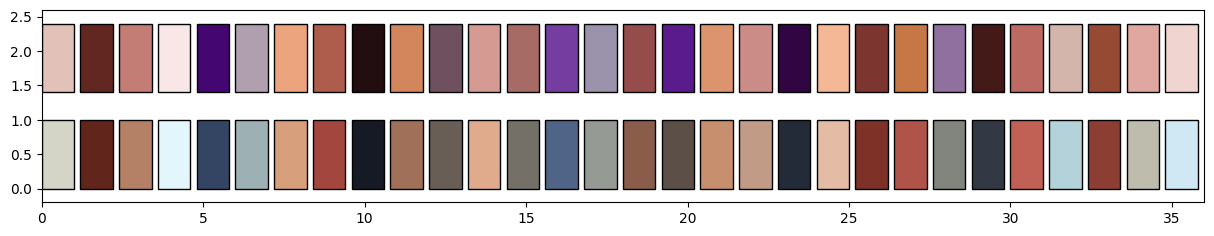

In [24]:
plot_color_checker(centroids1, centroids2, row_ind, col_ind)

In [45]:
x, residuals, rank, s = np.linalg.lstsq(centroids1[row_ind], centroids2[col_ind])

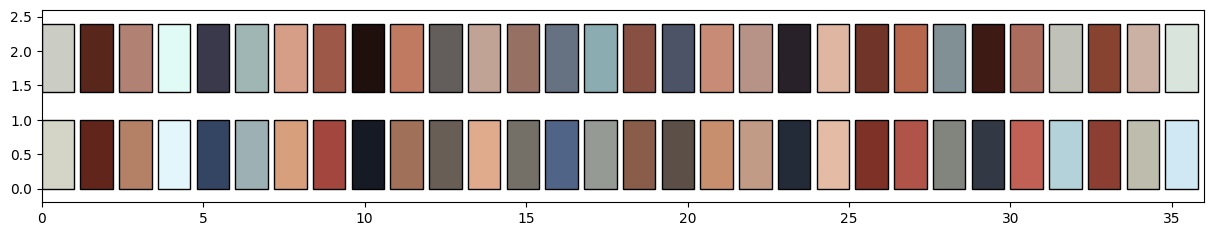

In [48]:
plot_color_checker(centroids1 @ x, centroids2, row_ind, col_ind)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.022987373..1.0635201].


(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

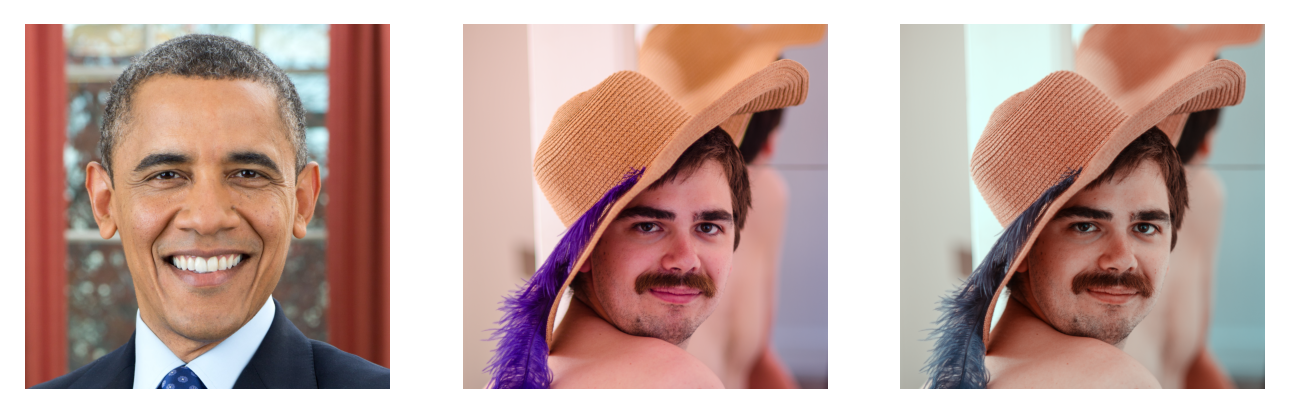

In [56]:
plt.figure(dpi=250)
plt.subplot(1, 3, 1)
plt.imshow(obama)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(lena)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow((lena.reshape(-1, 3) @ x).reshape(lena.shape))
plt.axis('off')

In [78]:
plt.imsave('Lena_in_Obama_colorspace_kmeans.png', np.clip((lena.reshape(-1, 3) @ x).reshape(lena.shape), 0, 1))

In [61]:
import cv2

In [62]:
lena.shape

(2048, 2048, 3)

In [64]:
lena_obama_size = cv2.resize(lena, obama.shape[:-1])

In [65]:
x2, residuals, rank, s = np.linalg.lstsq(lena_obama_size.reshape(-1,3), obama.reshape(-1,3))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.022664387..0.963855].


(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

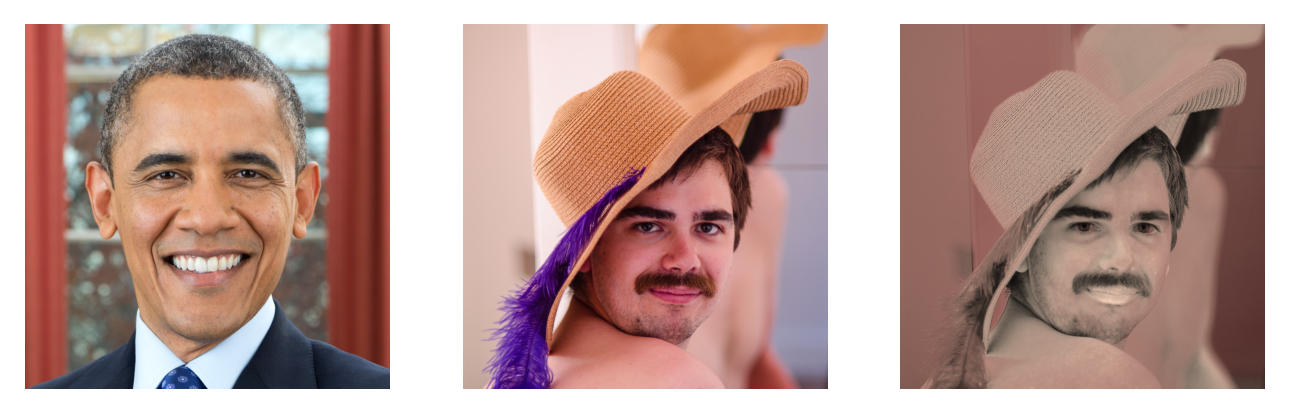

In [71]:
plt.figure(dpi=250)
plt.subplot(1, 3, 1)
plt.imshow(obama)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(lena)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow((lena.reshape(-1, 3) @ x2).reshape(lena.shape))
plt.axis('off')

In [72]:
plt.imsave('Lena_in_Obama_colorspace_naive.png', np.clip((lena.reshape(-1, 3) @ x2).reshape(lena.shape), 0, 1))

(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

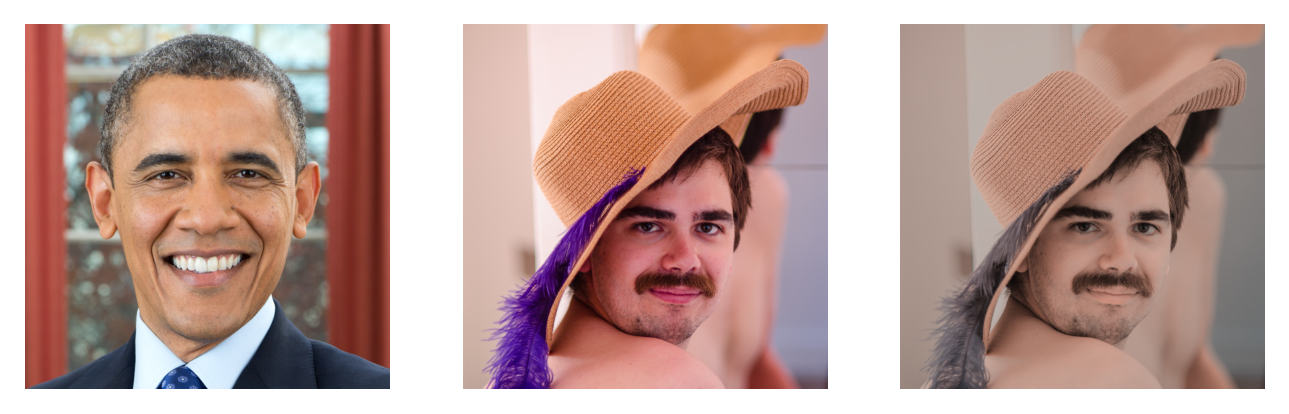

In [74]:
plt.figure(dpi=250)
plt.subplot(1, 3, 1)
plt.imshow(obama)
plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(lena)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow((lena.reshape(-1, 3) @ (x2+x)/2).reshape(lena.shape))
plt.axis('off')

In [77]:
plt.imsave('Lena_in_Obama_colorspace_combined.png', np.clip((lena.reshape(-1, 3) @ (x2+x)/2).reshape(lena.shape), 0, 1))